# Water Potability Prediction using Machine Learning

## **1. Introduction**

Access to safe drinking water is an important global issue.

Water quality depends on chemical properties such as **pH**, **hardness**, **sulfate**, and **turbidity**.

## **Target Variable**

- **Potability = 1** → Water is safe to drink  
- **Potability = 0** → Water is not safe to drink

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("../data/water_potability.csv")
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [3]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [5]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792305,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [6]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

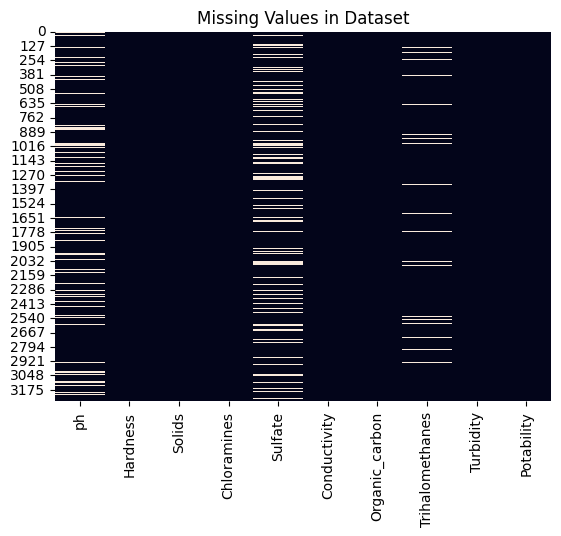

In [7]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values in Dataset")
plt.show()

In [8]:
df["Potability"].value_counts()

Potability
0    1998
1    1278
Name: count, dtype: int64

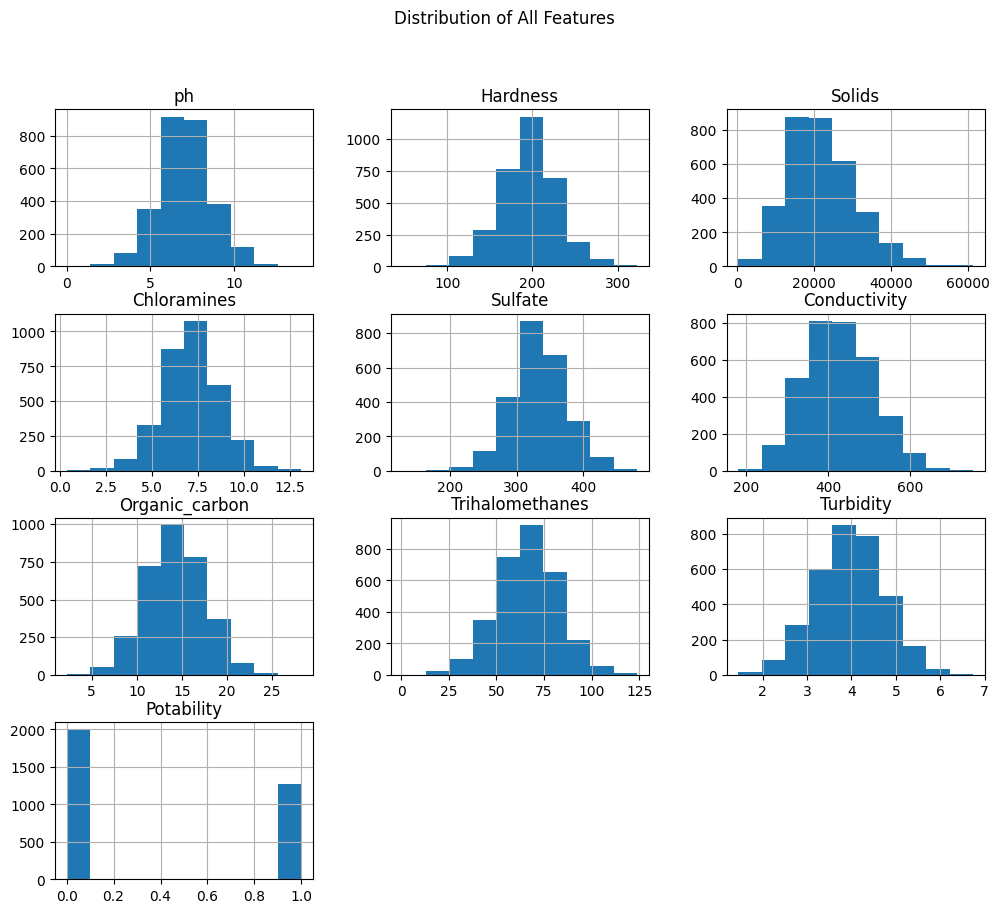

In [9]:
df.hist(figsize=(12,10))
plt.suptitle("Distribution of All Features")
plt.show()

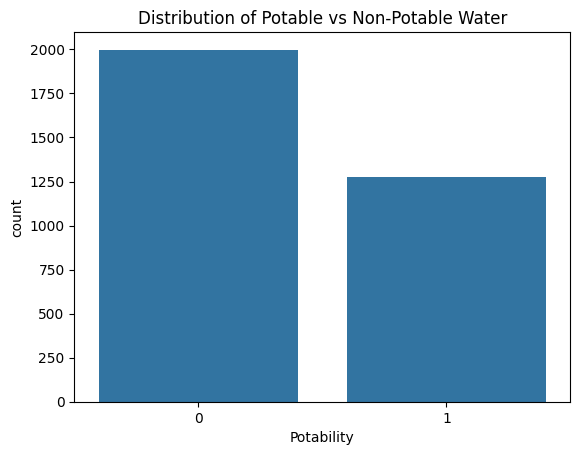

In [10]:
sns.countplot(x="Potability", data=df)
plt.title("Distribution of Potable vs Non-Potable Water")
plt.show()

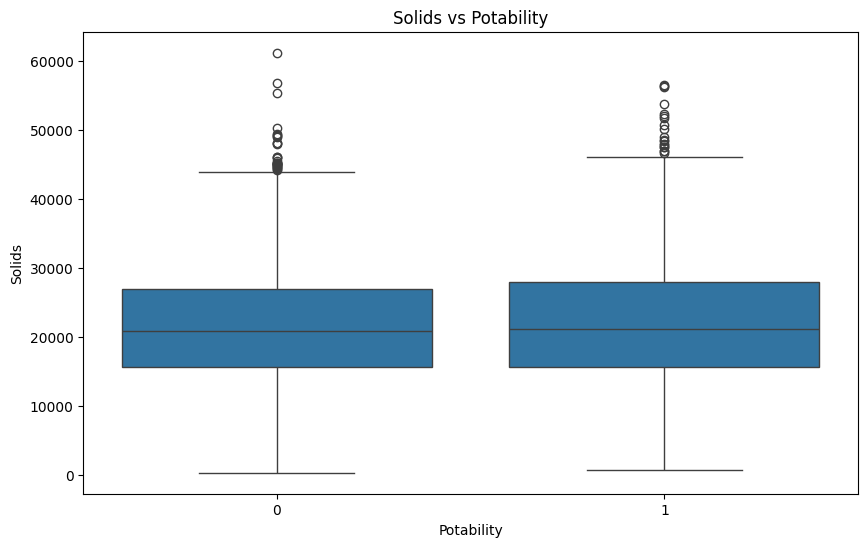

In [11]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Potability", y="Solids", data=df)
plt.title("Solids vs Potability")
plt.show()

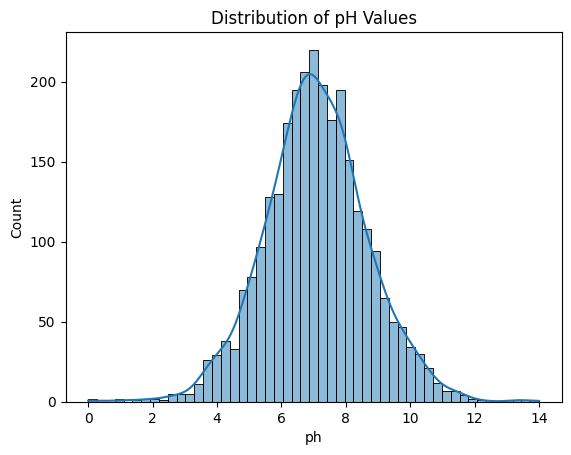

In [12]:
sns.histplot(df["ph"], kde=True)
plt.title("Distribution of pH Values")
plt.show()

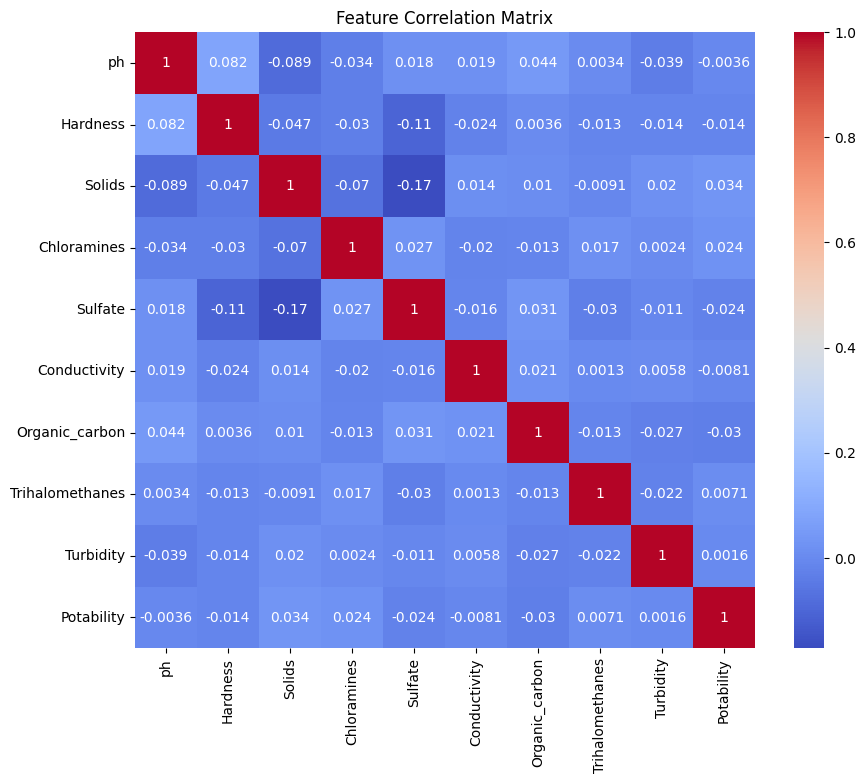

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

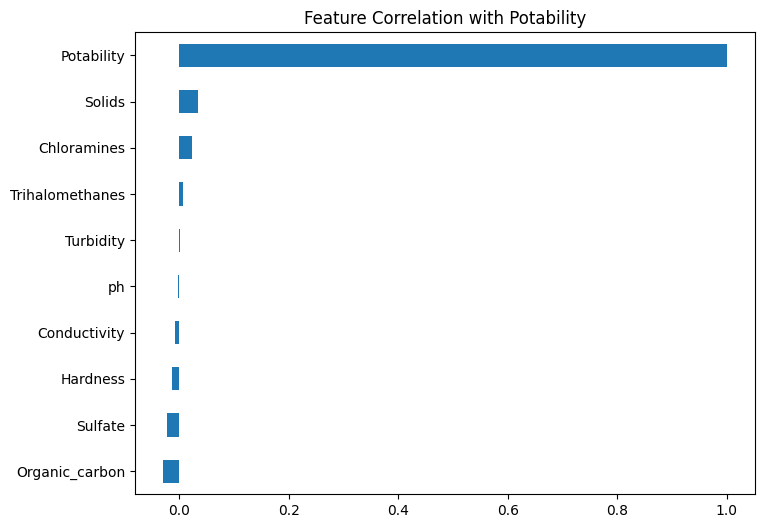

In [14]:
corr = df.corr()["Potability"].sort_values()

corr.plot(kind="barh", figsize=(8,6))
plt.title("Feature Correlation with Potability")
plt.show()

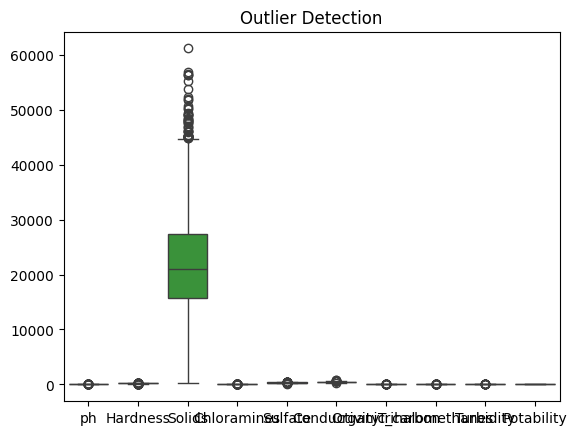

In [15]:
sns.boxplot(data=df)
plt.title("Outlier Detection")
plt.show()

## **2. Key Insights from EDA**

- **The dataset contains several missing values in features such as pH and Sulfate.**

- **The target variable is moderately imbalanced.**

- **Some features such as Solids and Hardness show wider distributions.**

- **Correlation between features is generally low, indicating low multicollinearity.**

## **3. Data Preprocessing**

Data preprocessing is an **essential step in the machine learning pipeline**. Raw data often contains **missing values**, **inconsistent formats**, or features that need to be **scaled** before training a model.

The goal of preprocessing is to **clean and transform the dataset** into a suitable format for machine learning algorithms.

### **Steps Included in This Project**

- **1. Separating Features and Target Variable**

The dataset was divided into:

Features (X): All chemical properties of water
Target (y): Potability (0 = Not drinkable, 1 = Drinkable)

In [16]:
X = df.drop("Potability", axis=1)
y = df["Potability"]

- **2. Splitting the Dataset**

The dataset was split into training and testing sets using an 80-20 ratio.

Training data → used to train the model
Testing data → used to evaluate performance

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

- **3. Handling Missing Values and Feature Scaling**

Some features such as pH, Sulfate, and Trihalomethanes contained missing values.
Instead of dropping rows (which would significantly reduce the dataset size), median imputation was applied.

Median is more robust to outliers compared to mean, making it suitable for this dataset.
To ensure consistency and avoid data leakage, preprocessing was performed after splitting the dataset.

**In addition, since features like solids, conductivity, and hardness have different ranges, feature scaling (standardization) was applied so that all features contribute equally to the model.**

Both steps — imputation and scaling — were combined using a single preprocessing pipeline for cleaner and more efficient implementation.

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Apply preprocessing
X_train = pipeline.fit_transform(X_train)
X_test = pipeline.transform(X_test)

## **4. Final Prepared Dataset**

After preprocessing, the dataset is **ready for machine learning**.

- **Missing values have been handled**
- **Features and target variables have been separated**
- **Data has been split into training and testing sets**
- **Feature scaling has been applied**

The processed dataset can now be used to train **classification models** such as **Logistic Regression**, **Random Forest**, or **Gradient Boosting**.

In [19]:
import pandas as pd

X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

In [ ]:
X_train_df = X_train_df.drop("Potability", axis=1)
X_train_df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,-0.311235,0.202046,-0.554634,-0.666527,-0.599837,-0.199296,0.506221,-0.085002,-1.341104
1,-0.269469,-0.080066,1.368736,1.743813,0.306595,0.882586,-1.654207,0.018387,0.090829
2,-0.165980,0.283021,-0.423990,-0.248791,-0.983558,0.838486,-0.134860,0.274308,1.274183
3,-0.039111,-0.397879,-1.063086,1.681607,-0.374831,0.690172,-0.286851,-1.231650,-0.923584
4,-0.459476,-0.416413,-0.477227,0.223520,-0.026279,-0.340518,0.928554,-0.145023,0.788260
...,...,...,...,...,...,...,...,...,...
2615,-1.976863,0.366111,-0.029081,-0.794690,-0.164762,-1.994638,-0.918494,-1.242431,0.812639
2616,0.488925,-0.966755,0.389467,0.478776,0.685749,-0.344453,0.318363,0.015968,0.333916
2617,-0.306619,-0.297420,1.004419,0.375135,-0.018756,-1.177037,-0.132780,1.286591,-0.602449
2618,1.165298,0.662635,-0.665997,0.177994,0.017017,-0.460730,0.640193,-1.216025,0.403374


In [28]:
X_test_df = X_test_df.drop("Potability", axis=1)
X_test_df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,-0.039111,-0.396889,-0.181736,0.141929,-0.008798,-0.862984,1.804635,0.041143,1.189622
1,-0.297871,-0.231339,1.223451,-0.199252,0.011353,-1.106997,0.138518,0.093209,0.773151
2,0.524577,0.847637,0.135567,-0.746663,-0.912681,-0.473669,-0.257313,-1.470110,-1.889486
3,0.055824,-0.410145,-1.734696,-2.081479,-1.542685,0.019900,-1.355564,1.493748,-0.096291
4,-0.316884,-0.528300,0.489763,1.386439,-0.018756,0.861638,-0.446127,0.750703,0.633546
...,...,...,...,...,...,...,...,...,...
651,2.015158,0.854007,-0.804269,0.201826,0.097664,1.122180,1.402581,-0.063403,0.285457
652,-0.145805,1.074396,0.058776,-0.901588,-0.018756,0.864593,0.579435,1.583770,1.227598
653,0.260036,0.652421,-0.297745,-1.554892,0.524549,0.833683,0.063462,-0.578873,-0.152566
654,-0.831528,-0.349484,2.490852,-1.716377,2.189536,-1.168487,0.320976,-0.426792,1.986511


In [ ]:
# X_train_df["Potability"] = y_train.values
# X_test_df["Potability"] = y_test.values

In [21]:
X_train_df.to_csv("../data/train_processed.csv", index=False)
X_test_df.to_csv("../data/test_processed.csv", index=False)